In [ ]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
from diffusers import AutoencoderKL
from types import SimpleNamespace
from torchdiffeq import odeint_adjoint as odeint # odeint_adjoint는 역전파 효율성을 위해 주로 사용됩니다.
from utils import visualize, show_tensor_image
from cleanfid import fid
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from einops import rearrange
import cv2
import json
from cfm_0707 import Cfm
import math
import time
import random
from transformers import get_cosine_schedule_with_warmup
import numpy as np

def count_parameters(model: nn.Module, only_trainable: bool = True):
    return f"{round(sum(p.numel() for p in model.parameters() if p.requires_grad or not only_trainable)/1000000, 3)}M"

cfg = {
    "in_dim":4,
    "model_dim": 512,
    "depth":16,
    "num_heads":8,
    "batch_size": 320,
    "learning_rate": 1e-4,
    "epochs": 50,
    "sampling_steps": 64,
    "latent_scale": 0.18215,
    "output_dir": "./logs_fm_0707_imagenet64",
    "beta_1": 0.9,
    "beta_2": 0.99,
    'weight_decay': 0.001,
    "sigma_min": 1e-5,
    "sampling_method": "uniform"
}
cfg = SimpleNamespace(**cfg)
device = 'cuda'

In [ ]:
device = 'cuda'

# downsampling rate=8, latent_dim=4
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(device)
vae.eval()

model = Cfm(
    in_dim=cfg.in_dim, 
    dim=cfg.model_dim, 
    depth=cfg.depth, 
    heads=cfg.num_heads,
    num_classes=1000,
    attn_dropout=0.0,
    ff_dropout=0.1
)
model.to(device)
print(count_parameters(model))

os.makedirs(cfg.output_dir, exist_ok=True)
os.makedirs(f"{cfg.output_dir}/valid_imgs/", exist_ok=True)
os.makedirs(f"{cfg.output_dir}/weights/", exist_ok=True)

with open(f"{cfg.output_dir}/model_structure.txt", "a") as f:
    print(model, file=f)

trainer = {
    'train_losses': [],
    'train_times': [],
    'train_losses_per_timesteps': [],
    'valid_losses': [],
    'valid_images': [],
    'fid_scores': [],
}

In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import torch

# Transform 정의
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# HuggingFace Dataset → PyTorch Dataset으로 감싸기
class HFDatasetWrapper(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = example["image"]
        label = example["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

# 데이터셋 로딩
dataset = load_dataset("benjamin-paine/imagenet-1k-64x64")

# train/val wrapping
train_dataset = HFDatasetWrapper(dataset["train"], transform=transform)
val_dataset = HFDatasetWrapper(dataset["validation"], transform=transform)

# DataLoader 생성
train_dataloader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=8, pin_memory=True)
valid_dataloader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=8, pin_memory=True)


show_tensor_image(next(iter(valid_dataloader))[0]['image'])

In [ ]:


optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, betas=(cfg.beta_1, cfg.beta_2), weight_decay=cfg.weight_decay)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_dataloader),
    num_training_steps=cfg.epochs*len(train_dataloader)
)

def write(text):
    with open(f'{cfg.output_dir}/logs.txt', 'a') as file:
        file.write(text)

In [ ]:
last_saved_epoch = 0
vae.eval()

def valid_step(epoch):
    model.eval()
    valid_loss = 0
    tqdm_bar = tqdm(total=len(valid_dataloader), desc="Diffusion validation")
    with torch.no_grad():
        for idx, data in enumerate(valid_dataloader):
            # data, labels = batch[0], batch[1]
            x_0 = data.to(device)
            with torch.no_grad():
                z_0 = vae.encode(x_0)
                z_0 = z_0['latent_dist'].sample() * cfg.latent_scale
            
            b, c, h, w = z_0.shape
            z_0 = z_0.permute(0, 2, 3, 1).reshape(b, h*w, c)
            z_T = torch.randn_like(z_0, device=z_0.device, dtype=z_0.dtype)

            t = torch.rand((b, ), dtype=z_0.dtype, device=z_0.device)
            t = rearrange(t, "b -> b () ()")
            target_vf = z_0 - (1 - cfg.sigma_min) * z_T
            z_t = (1 - (1 - cfg.sigma_min)*t) * z_T + t * z_0
            
            predicted_vf = model(t.squeeze(), z_t)
            
            loss = torch.nn.functional.mse_loss(target_vf, predicted_vf)
            
            valid_loss += loss.cpu().detach().item()
            tqdm_bar.update(1)

            # Inference Sampling for visual evaluation
            if idx==0:
                y0 = torch.randn_like(z_0, device=z_0.device)
                t = torch.linspace(0, 1, 64, device=z_0.device, dtype=z_0.dtype)
                
                with torch.no_grad(): # 추론 시에는 역전파가 필요 없으므로 no_grad 사용
                    solution = odeint(model, y0, t, method='rk4')
                
                solution = rearrange(solution[-1], "b (x y) c -> b c x y", x=w, y=h)
                predicted_image = vae.decode(solution / cfg.latent_scale)['sample']
                predicted_image = (predicted_image[:8].cpu().detach()).clamp(0, 1)
                
                # -1 ~ 1로 나오니까 0~1로 만들기
                trainer['valid_images'].append(predicted_image)
        
        # Get FID per 3epochs
        if epoch % 3 == 1:
            save_dir = f"{cfg.output_dir}/validsets_{epoch}"
            os.makedirs(save_dir, exist_ok=True)
            for cnt in range(8):
                y0 = torch.randn((256, 64, 4), device=device)
                t = torch.linspace(0, 1, 64, device=device, dtype=torch.float32)
                
                with torch.inference_mode(): # 추론 시에는 역전파가 필요 없으므로 no_grad 사용
                    solution = odeint(model, y0, t, method='rk4')
                
                solution = rearrange(solution[-1], "b (x y) c -> b c x y", x=w, y=h)
                predicted_image = vae.decode(solution / cfg.latent_scale)['sample']
                predicted_image = (predicted_image.cpu().detach()).clamp(0, 1) # bs, 3, 64, 64

                for i in range(predicted_image.shape[0]-1):
                    image = predicted_image[i].squeeze()
                    # image = image.permute(1,2,0)
                    pil_image = TF.to_pil_image(image)  # to_pil_image expects [C,H,W]
                    pil_image.save(os.path.join(save_dir, f"image_{cnt}_{i}.png"))
            # get FID
            fid_score = fid.compute_fid(
                "/workspace/personal_tests/valid_images/", 
                save_dir
            )
            trainer['fid_scores'].append(fid_score)
    
    torch.cuda.empty_cache()
    
    # per data loss
    val_loss = valid_loss/len(valid_dataloader)
    trainer['valid_losses'].append(val_loss)
    
    if val_loss <= min(trainer['valid_losses']):
        torch.save(model.state_dict(), f'{cfg.output_dir}/weights/model_{epoch}.pth')
    
    valid_text=f'Epoch {epoch} Validation loss - {val_loss}\n\n'
    write(valid_text)
    
    plt.plot(trainer['valid_losses'])
    plt.savefig(f'{cfg.output_dir}/valid_loss.png')
    plt.close()
    
    plt.plot(trainer['fid_scores'])
    plt.savefig(f'{cfg.output_dir}/fid_scores.png')
    plt.close()
    
    visualize(trainer['valid_images'][-1], epoch=epoch, save=True, output_dir=cfg.output_dir)

In [ ]:

vae.eval()
last_saved_epoch = 0
with open(f'{cfg.output_dir}/configs.json', "w"):
    json.dump(cfg, f)

for epoch in range(cfg.epochs):
    model.train()
    epoch_loss = 0
    train_losses_per_timesteps = [0]*10
    train_losses_per_timesteps_count = [0]*10
    tqdm_bar = tqdm(total=len(train_dataloader), desc="Latent DiT DDPM Training")
    
    start_at = time.time()
    for idx, data in enumerate(train_dataloader):
        # data, labels = batch[0], batch[1]
        x_0 = data.to(device)

        # # 2) VAE encode
        with torch.no_grad():
            z_0 = vae.encode(x_0)
            z_0 = z_0['latent_dist'].sample() * cfg.latent_scale

        # Flatten latent
        b, c, h, w = z_0.shape
        z_0 = z_0.permute(0, 2, 3, 1).reshape(b, h*w, c)
        z_T = torch.randn_like(z_0, device=z_0.device, dtype=z_0.dtype)

        # timestep은 0~1000이 아니라 0~1 사이 실수 값 uniform
        if cfg.sampling_method == 'uniform':
            t = torch.rand((b, ), dtype=z_0.dtype, device=device)
        elif cfg.sampling_method == "lognorm":
            if random.random()<0.2:
                t = torch.rand((b, ), dtype=z_0.dtype, device=device)
            else:
                tnorm = np.random.normal(loc=0, scale=1.0, size=b)
                t = 1 / (1 + np.exp(-tnorm))
                t = torch.tensor(t, dtype=z_0.dtype, device=device)

            # tnorm = torch.randn((b, ), dtype=z_0.dtype, device=device)
            # t = 1 / (1 + torch.exp(-tnorm))
        
        t = rearrange(t, "b -> b () ()")
        z_t = (1 - (1 - cfg.sigma_min)*t) * z_T + t * z_0
        target_vf = z_0 - (1 - cfg.sigma_min) * z_T
                
        # 4) 모델 예측
        predicted_vf = model(t.squeeze(), z_t)

        # Loss 계산
        loss = torch.nn.functional.mse_loss(target_vf, predicted_vf, reduction='none').mean(dim=(1, 2))
        if idx>5:
            for idxin, ptl in enumerate(loss):
                train_losses_per_timesteps[min(math.floor(t[idxin]*10), 9)] += ptl.cpu().detach().item()
                train_losses_per_timesteps_count[min(math.floor(t[idxin]*10), 9)] += 1
        
        loss = loss.mean()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        tqdm_bar.update()
        tqdm_bar.set_postfix(loss=loss.item())
        epoch_loss += loss.cpu().detach().item()
        # print("loss - ", loss)

    trainer['train_times'].append(time.time() - start_at)

    trainer['train_losses'].append(epoch_loss/len(train_dataloader))
    trainer['train_losses_per_timesteps'].append(train_losses_per_timesteps)
    train_text = f'Epoch {epoch} Train loss - {epoch_loss / len(train_dataloader)}\n'
    for i in range(10):
        count = train_losses_per_timesteps_count[i]
        avg = train_losses_per_timesteps[i] / count if count > 0 else 0
        train_text += f"timesteps {i/10:.1f} ~ {i/10+0.1:.1f} : {avg:.4f}\n"
    
    write(train_text)
    
    plt.plot(trainer['train_losses'])
    plt.savefig(f'{cfg.output_dir}/train_loss.png')
    plt.close()

    torch.cuda.empty_cache()
    valid_step(epoch)

    with open(f'{cfg.output_dir}/trainer.json', "w"):
        json.dump(trainer, f)

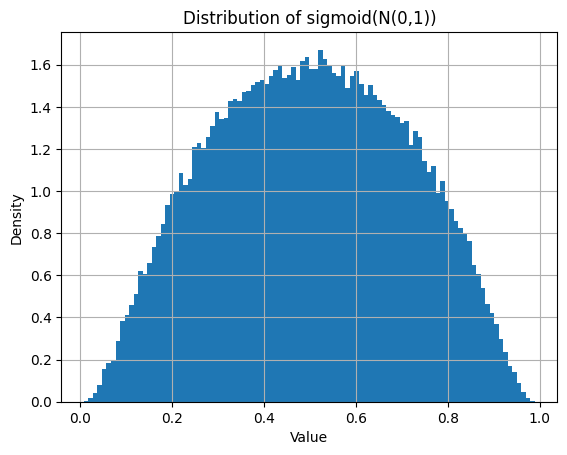

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 표준 정규분포에서 샘플
x = np.random.normal(loc=0, scale=1.0, size=100000)

# 로지스틱 함수 통과
y = 1 / (1 + np.exp(-x))
# y = y + np.random.sample(100000)

# 히스토그램 그리기
plt.hist(y, bins=100, density=True)
plt.title("Distribution of sigmoid(N(0,1))")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()
